<a href="https://www.kaggle.com/code/kedhareswernaidu/moonknight?scriptVersionId=231399581" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Like Paintings

### Environment Setup and Imports

In [1]:
import tensorflow as tf
print(tf.__version__)

2.17.1


In [2]:
pip install tfa-nightly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.3/620.3 kB 28.5 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.1
    Uninstalling typeguard-4.4.1:
      Successfully uninstalled typeguard-4.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.4.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.
ydata-profiling 4.12.2 requires typeguard<5,>=3, but you have typeguard 2.13.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model, initializers

# --------------------------
# 1. Self-Attention Layer (Fixed)
# --------------------------
class SelfAttention(layers.Layer):
    def __init__(self, filters):
        """ Self-Attention Layer for capturing global dependencies. """
        super(SelfAttention, self).__init__()
        self.filters = filters
        self.query = layers.Conv2D(filters // 8, (1, 1), padding="same")
        self.key = layers.Conv2D(filters // 8, (1, 1), padding="same")
        self.value = layers.Conv2D(filters, (1, 1), padding="same")
        self.gamma = self.add_weight(shape=(1,), initializer="zeros", trainable=True)

    def call(self, x):
        batch_size, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]

        q = tf.reshape(self.query(x), (batch_size, height * width, channels // 8))  # [B, HW, C/8]
        k = tf.reshape(self.key(x), (batch_size, height * width, channels // 8))    # [B, HW, C/8]
        v = tf.reshape(self.value(x), (batch_size, height * width, channels))       # [B, HW, C]

        attention_map = tf.nn.softmax(tf.matmul(q, k, transpose_b=True))  # [B, HW, HW]
        out = tf.matmul(attention_map, v)  # [B, HW, C]

        out = tf.reshape(out, (batch_size, height, width, channels))  # Restore original shape
        return self.gamma * out + x  # Weighted residual connection

# --------------------------
# 2. Adaptive Instance Normalization (AdaIN)
# --------------------------
class AdaIN(layers.Layer):
    def __init__(self, epsilon=1e-5):
        super(AdaIN, self).__init__()
        self.epsilon = epsilon

    def call(self, x):
        mean, var = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        std = tf.sqrt(var + self.epsilon)
        return (x - mean) / std

# --------------------------
# 3. ResNet Block with AdaIN and Self-Attention
# --------------------------
def resnet_block(filters):
    def block(x):
        res = layers.Conv2D(filters, (3, 3), padding="same")(x)
        res = AdaIN()(res)
        res = layers.ReLU()(res)
        res = SelfAttention(filters)(res)  # Add Self-Attention
        res = layers.Conv2D(filters, (3, 3), padding="same")(res)
        res = AdaIN()(res)
        return layers.Add()([x, res])  # Residual Connection
    return block

# --------------------------
# 4. Generator Model (U-Net + ResNet)
# --------------------------
def build_generator():
    inputs = layers.Input(shape=(256, 256, 3))

    # Encoder
    x = layers.Conv2D(64, (7, 7), padding="same", strides=1)(inputs)
    x = AdaIN()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(128, (3, 3), padding="same", strides=2)(x)
    x = AdaIN()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, (3, 3), padding="same", strides=2)(x)
    x = AdaIN()(x)
    x = layers.ReLU()(x)

    # Residual Blocks
    for _ in range(6):
        x = resnet_block(256)(x)

    # Decoder
    x = layers.Conv2DTranspose(128, (3, 3), padding="same", strides=2)(x)
    x = AdaIN()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(64, (3, 3), padding="same", strides=2)(x)
    x = AdaIN()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(3, (7, 7), padding="same", activation="tanh")(x)

    return Model(inputs, x, name="Generator")

# --------------------------
# 5. Discriminator Model (PatchGAN)
# --------------------------
def build_discriminator():
    inputs = layers.Input(shape=(256, 256, 3))

    x = layers.Conv2D(64, (4, 4), strides=2, padding="same")(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(128, (4, 4), strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(256, (4, 4), strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(512, (4, 4), strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Conv2D(1, (4, 4), strides=1, padding="same", activation="sigmoid")(x)

    return Model(inputs, x, name="Discriminator")

# --------------------------
# 6. Instantiate Models
# --------------------------
generator_G = build_generator()  # Photo → Monet
generator_F = build_generator()  # Monet → Photo
discriminator_X = build_discriminator()  # Discriminator for real vs fake photos
discriminator_Y = build_discriminator()  # Discriminator for real vs fake Monet paintings

print("✅ Models initialized successfully!")

✅ Models initialized successfully!


/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [4]:
import tensorflow as tf
from tensorflow.keras import optimizers

# --------------------------
# 1. Adversarial Loss (Least Squares GAN)
# --------------------------
mse_loss = tf.keras.losses.MeanSquaredError()

def generator_loss(fake_output):
    """ Adversarial loss for generators (LS-GAN). """
    return mse_loss(tf.ones_like(fake_output), fake_output)  # Try to fool discriminator

def discriminator_loss(real_output, fake_output):
    """ Discriminator loss (LS-GAN). """
    real_loss = mse_loss(tf.ones_like(real_output), real_output)  # Real images should be 1
    fake_loss = mse_loss(tf.zeros_like(fake_output), fake_output)  # Fake images should be 0
    return (real_loss + fake_loss) * 0.5  # Average loss

# --------------------------
# 2. Cycle Consistency Loss (Content Preservation)
# --------------------------
mae_loss = tf.keras.losses.MeanAbsoluteError()

def cycle_loss(real_image, cycled_image, lambda_cycle=10):
    """ Ensures translated image can be reconstructed back to original. """
    return lambda_cycle * mae_loss(real_image, cycled_image)

# --------------------------
# 3. Identity Loss (Style Preservation)
# --------------------------
def identity_loss(real_image, same_image, lambda_identity=5):
    """ Encourages generators to retain color composition. """
    return lambda_identity * mae_loss(real_image, same_image)

# --------------------------
# 4. Optimizers (Separate for each model)
# --------------------------
generator_G_optimizer = optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
generator_F_optimizer = optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_X_optimizer = optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_Y_optimizer = optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

print("✅ Loss functions & optimizers initialized!")

✅ Loss functions & optimizers initialized!


In [5]:
import tensorflow as tf

# --------------------------
# 1. Training Step Function
# --------------------------
@tf.function
def train_step(real_x, real_y):
    """Performs one training step: forward pass, compute losses, and backpropagation."""

    with tf.GradientTape(persistent=True) as tape:
        # -------------------------------
        # Forward Pass - Generators
        # -------------------------------
        fake_y = generator_G(real_x, training=True)  # X → Y
        cycled_x = generator_F(fake_y, training=True)  # Y' → X
        
        fake_x = generator_F(real_y, training=True)  # Y → X
        cycled_y = generator_G(fake_x, training=True)  # X' → Y

        # Identity Mapping (Preserve colors for images already in target domain)
        same_y = generator_G(real_y, training=True)  # Y → Y
        same_x = generator_F(real_x, training=True)  # X → X
        
        # -------------------------------
        # Forward Pass - Discriminators
        # -------------------------------
        disc_real_x = discriminator_X(real_x, training=True)  # Real X
        disc_fake_x = discriminator_X(fake_x, training=True)  # Fake X (generated)

        disc_real_y = discriminator_Y(real_y, training=True)  # Real Y
        disc_fake_y = discriminator_Y(fake_y, training=True)  # Fake Y (generated)

        # -------------------------------
        # Compute Losses
        # -------------------------------
        # Generator Adversarial Loss
        gen_G_loss = generator_loss(disc_fake_y)
        gen_F_loss = generator_loss(disc_fake_x)

        # Cycle Consistency Loss
        cycle_X_loss = cycle_loss(real_x, cycled_x)
        cycle_Y_loss = cycle_loss(real_y, cycled_y)
        total_cycle_loss = cycle_X_loss + cycle_Y_loss

        # Identity Loss
        id_X_loss = identity_loss(real_x, same_x)
        id_Y_loss = identity_loss(real_y, same_y)
        total_identity_loss = id_X_loss + id_Y_loss

        # Total Generator Loss
        total_gen_G_loss = gen_G_loss + total_cycle_loss + total_identity_loss
        total_gen_F_loss = gen_F_loss + total_cycle_loss + total_identity_loss

        # Discriminator Loss
        disc_X_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_Y_loss = discriminator_loss(disc_real_y, disc_fake_y)

    # --------------------------
    # Compute Gradients
    # --------------------------
    generator_G_gradients = tape.gradient(total_gen_G_loss, generator_G.trainable_variables)
    generator_F_gradients = tape.gradient(total_gen_F_loss, generator_F.trainable_variables)
    discriminator_X_gradients = tape.gradient(disc_X_loss, discriminator_X.trainable_variables)
    discriminator_Y_gradients = tape.gradient(disc_Y_loss, discriminator_Y.trainable_variables)

    # --------------------------
    # Apply Gradients (Backpropagation)
    # --------------------------
    generator_G_optimizer.apply_gradients(zip(generator_G_gradients, generator_G.trainable_variables))
    generator_F_optimizer.apply_gradients(zip(generator_F_gradients, generator_F.trainable_variables))
    discriminator_X_optimizer.apply_gradients(zip(discriminator_X_gradients, discriminator_X.trainable_variables))
    discriminator_Y_optimizer.apply_gradients(zip(discriminator_Y_gradients, discriminator_Y.trainable_variables))

    return {
        "G_G_loss": total_gen_G_loss,
        "G_F_loss": total_gen_F_loss,
        "D_X_loss": disc_X_loss,
        "D_Y_loss": disc_Y_loss
    }

print("✅ Training step function initialized!")

✅ Training step function initialized!


In [6]:
import tensorflow as tf
import tensorflow_addons as tfa
import glob
import random
import os

# --------------------------
# 1. Dataset Paths
# --------------------------
PHOTO_DIR = "/kaggle/input/c/gan-getting-started/photo_jpg"  
MONET_DIR = "/kaggle/input/c/gan-getting-started/monet_jpg" 

# --------------------------
# 2. Image Preprocessing Function
# --------------------------
def preprocess_image(image):
    """Resizes image to 256x256 and normalizes pixel values to [-1, 1]."""
    image = tf.image.resize(image, (256, 256))
    image = (image - 127.5) / 127.5  # Normalize to [-1, 1]
    return image

# --------------------------
# 3. Data Augmentation
# --------------------------
def augment_image(image):
    """Applies random jitter and flip to the image."""
    image = tf.image.random_flip_left_right(image)  # Horizontal flip
    image = tf.image.random_saturation(image, 0.8, 1.2)  # Random saturation
    image = tf.image.random_brightness(image, 0.1)  # Random brightness
    return image

# --------------------------
# 4. Load Dataset from Files
# --------------------------
def load_image(filename):
    """Loads and preprocesses image from file."""
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = preprocess_image(image)
    return image

# --------------------------
# 5. Build TensorFlow Dataset Pipeline
# --------------------------
def get_dataset(image_paths, batch_size=1, augment=False):
    """Creates a TensorFlow dataset pipeline with optional augmentation."""
    dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.shuffle(len(image_paths)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# --------------------------
# 6. Load Datasets
# --------------------------
photo_paths = glob.glob(os.path.join(PHOTO_DIR, "*.jpg"))
monet_paths = glob.glob(os.path.join(MONET_DIR, "*.jpg"))

photo_ds = get_dataset(photo_paths, batch_size=1, augment=True)
monet_ds = get_dataset(monet_paths, batch_size=1, augment=True)

print(f"✅ Loaded {len(photo_paths)} photo images and {len(monet_paths)} Monet images.")

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.17.1 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

✅ Loaded 7038 photo images and 300 Monet images.


/usr/local/lib/python3.10/dist-packages/keras/src/backend/tensorflow/nn.py:707: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(



Epoch 1/50
Generator G Loss: 9.2399
Generator F Loss: 9.1440
Discriminator X Loss: 0.6555
Discriminator Y Loss: 0.6209

Epoch 2/50
Generator G Loss: 9.0988
Generator F Loss: 8.8519
Discriminator X Loss: 0.5648
Discriminator Y Loss: 0.4936

Epoch 3/50
Generator G Loss: 10.3144
Generator F Loss: 9.9600
Discriminator X Loss: 0.5007
Discriminator Y Loss: 0.3950

Epoch 4/50
Generator G Loss: 10.6218
Generator F Loss: 9.8113
Discriminator X Loss: 0.4993
Discriminator Y Loss: 0.3432

Epoch 5/50
Generator G Loss: 9.7038
Generator F Loss: 9.4222
Discriminator X Loss: 0.4943
Discriminator Y Loss: 0.4758

🔹 Generating sample images...


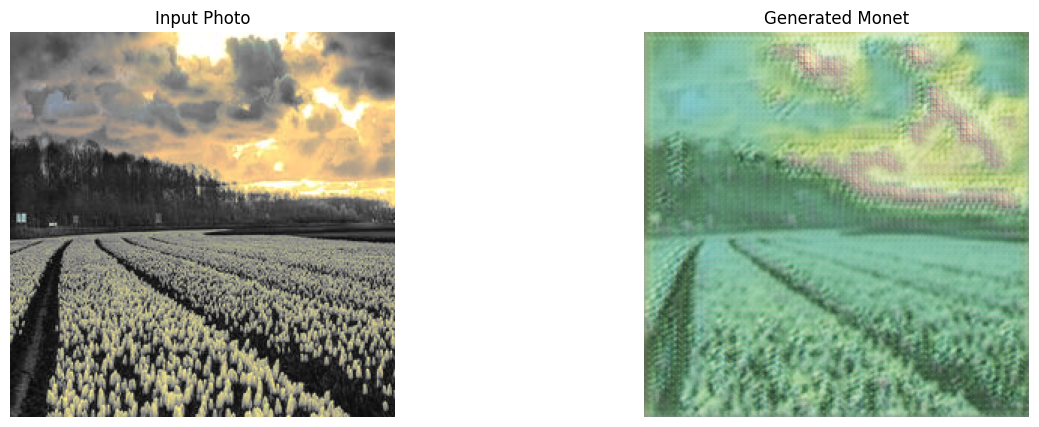

✅ Models saved at epoch 5

Epoch 6/50
Generator G Loss: 9.0180
Generator F Loss: 8.6876
Discriminator X Loss: 0.5748
Discriminator Y Loss: 0.4890

Epoch 7/50
Generator G Loss: 9.5521
Generator F Loss: 9.1608
Discriminator X Loss: 0.5158
Discriminator Y Loss: 0.4503

Epoch 8/50
Generator G Loss: 9.5134
Generator F Loss: 9.1755
Discriminator X Loss: 0.5164
Discriminator Y Loss: 0.4589

Epoch 9/50
Generator G Loss: 9.2876
Generator F Loss: 8.9534
Discriminator X Loss: 0.5301
Discriminator Y Loss: 0.4642

Epoch 10/50
Generator G Loss: 9.1290
Generator F Loss: 8.8177
Discriminator X Loss: 0.5378
Discriminator Y Loss: 0.4629

🔹 Generating sample images...


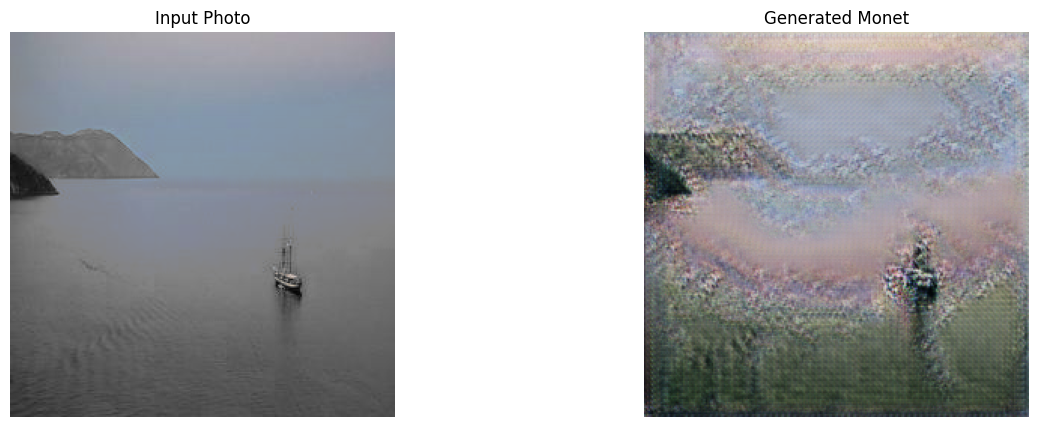

✅ Models saved at epoch 10

Epoch 11/50
Generator G Loss: 9.7215
Generator F Loss: 9.2042
Discriminator X Loss: 0.5280
Discriminator Y Loss: 0.3942

Epoch 12/50
Generator G Loss: 10.2909
Generator F Loss: 9.6067
Discriminator X Loss: 0.4843
Discriminator Y Loss: 0.3929

Epoch 13/50
Generator G Loss: 9.8353
Generator F Loss: 9.3224
Discriminator X Loss: 0.5035
Discriminator Y Loss: 0.3707

Epoch 14/50
Generator G Loss: 10.8641
Generator F Loss: 10.2831
Discriminator X Loss: 0.4231
Discriminator Y Loss: 0.3380

Epoch 15/50
Generator G Loss: 10.4769
Generator F Loss: 9.9550
Discriminator X Loss: 0.4628
Discriminator Y Loss: 0.3514

🔹 Generating sample images...


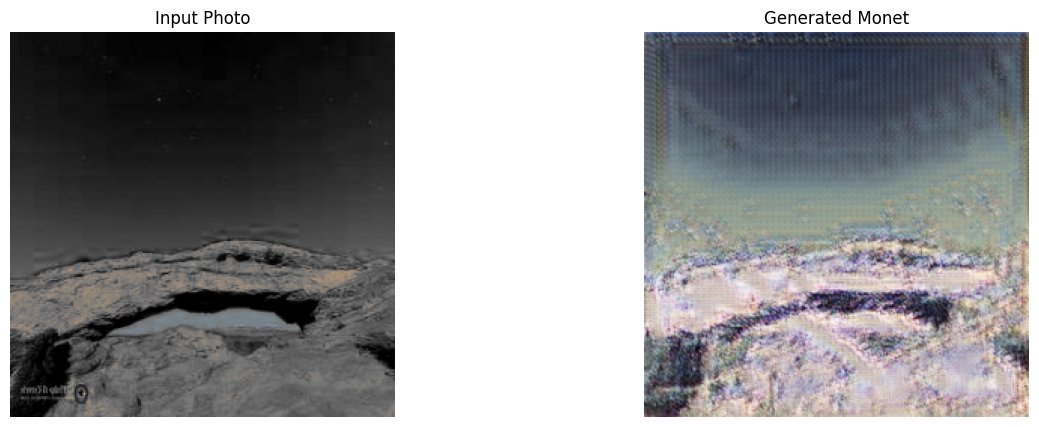

✅ Models saved at epoch 15

Epoch 16/50
Generator G Loss: 10.6475
Generator F Loss: 10.1156
Discriminator X Loss: 0.3996
Discriminator Y Loss: 0.3358

Epoch 17/50
Generator G Loss: 10.8198
Generator F Loss: 9.7972
Discriminator X Loss: 0.4676
Discriminator Y Loss: 0.2942

Epoch 18/50
Generator G Loss: 10.3134
Generator F Loss: 9.4699
Discriminator X Loss: 0.4865
Discriminator Y Loss: 0.3146

Epoch 19/50
Generator G Loss: 10.4737
Generator F Loss: 9.5035
Discriminator X Loss: 0.4689
Discriminator Y Loss: 0.3110

Epoch 20/50
Generator G Loss: 10.6923
Generator F Loss: 9.5824
Discriminator X Loss: 0.4235
Discriminator Y Loss: 0.2741

🔹 Generating sample images...


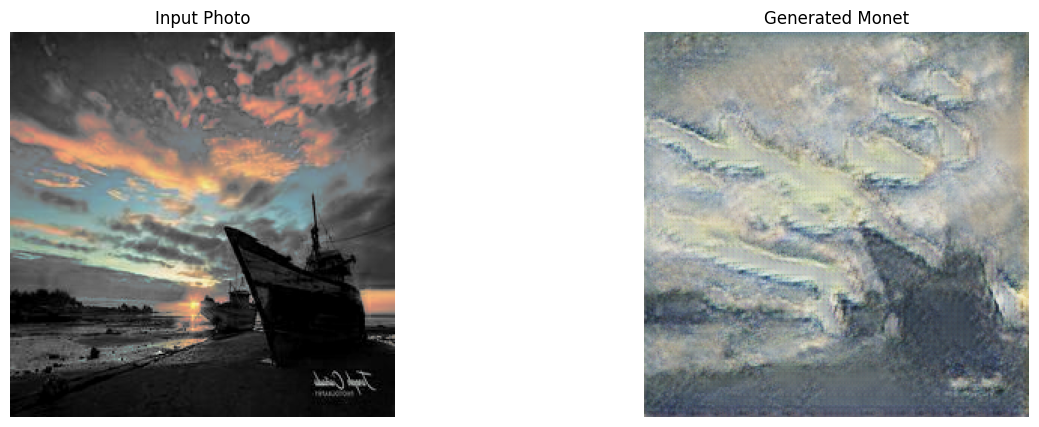

✅ Models saved at epoch 20

Epoch 21/50
Generator G Loss: 11.1699
Generator F Loss: 9.5770
Discriminator X Loss: 0.4880
Discriminator Y Loss: 0.1816

Epoch 22/50
Generator G Loss: 11.5120
Generator F Loss: 9.3997
Discriminator X Loss: 0.4883
Discriminator Y Loss: 0.1471

Epoch 23/50
Generator G Loss: 12.2456
Generator F Loss: 9.4970
Discriminator X Loss: 0.4824
Discriminator Y Loss: 0.1268

Epoch 24/50
Generator G Loss: 12.5887
Generator F Loss: 9.5016
Discriminator X Loss: 0.4583
Discriminator Y Loss: 0.0854

Epoch 25/50
Generator G Loss: 12.4011
Generator F Loss: 9.9042
Discriminator X Loss: 0.3819
Discriminator Y Loss: 0.1264

🔹 Generating sample images...


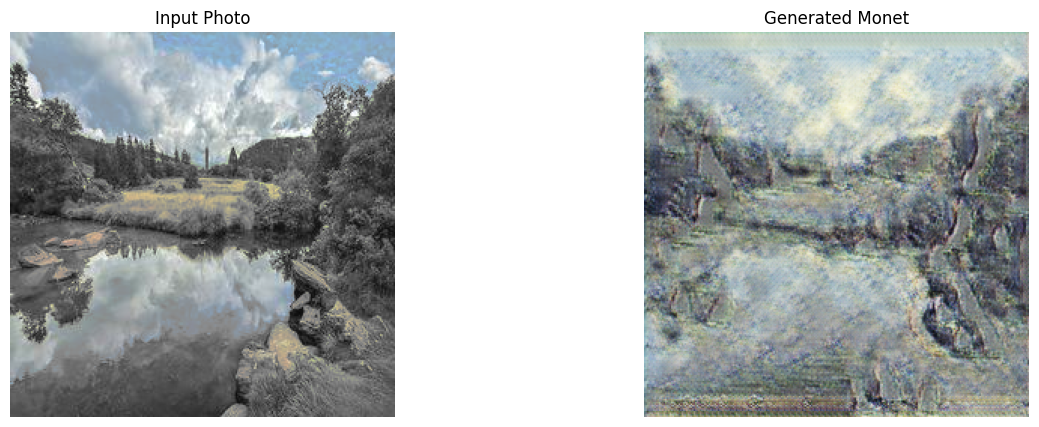

✅ Models saved at epoch 25

Epoch 26/50
Generator G Loss: 12.5412
Generator F Loss: 9.4692
Discriminator X Loss: 0.4872
Discriminator Y Loss: 0.0694

Epoch 27/50
Generator G Loss: 11.9890
Generator F Loss: 9.0949
Discriminator X Loss: 0.4736
Discriminator Y Loss: 0.1363

Epoch 28/50
Generator G Loss: 12.6500
Generator F Loss: 9.3007
Discriminator X Loss: 0.4628
Discriminator Y Loss: 0.0588

Epoch 29/50
Generator G Loss: 12.9058
Generator F Loss: 9.3167
Discriminator X Loss: 0.4475
Discriminator Y Loss: 0.0359

Epoch 30/50
Generator G Loss: 12.9952
Generator F Loss: 9.3554
Discriminator X Loss: 0.4355
Discriminator Y Loss: 0.0731

🔹 Generating sample images...


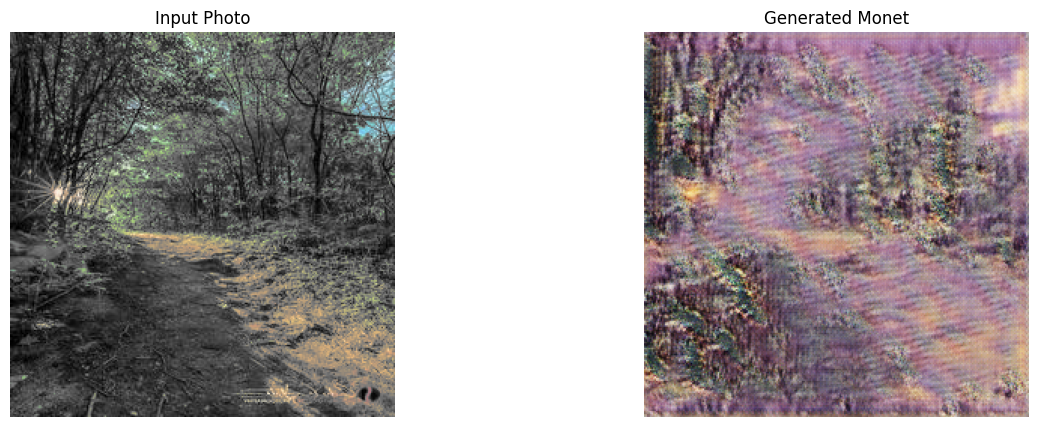

✅ Models saved at epoch 30

Epoch 31/50
Generator G Loss: 13.0253
Generator F Loss: 9.2056
Discriminator X Loss: 0.4170
Discriminator Y Loss: 0.0215

Epoch 32/50
Generator G Loss: 13.2029
Generator F Loss: 9.0908
Discriminator X Loss: 0.4503
Discriminator Y Loss: 0.0210

Epoch 33/50
Generator G Loss: 12.4896
Generator F Loss: 8.9147
Discriminator X Loss: 0.4550
Discriminator Y Loss: 0.1716

Epoch 34/50
Generator G Loss: 12.5141
Generator F Loss: 9.1867
Discriminator X Loss: 0.4683
Discriminator Y Loss: 0.0403

Epoch 35/50
Generator G Loss: 12.8389
Generator F Loss: 8.8575
Discriminator X Loss: 0.4850
Discriminator Y Loss: 0.0390

🔹 Generating sample images...


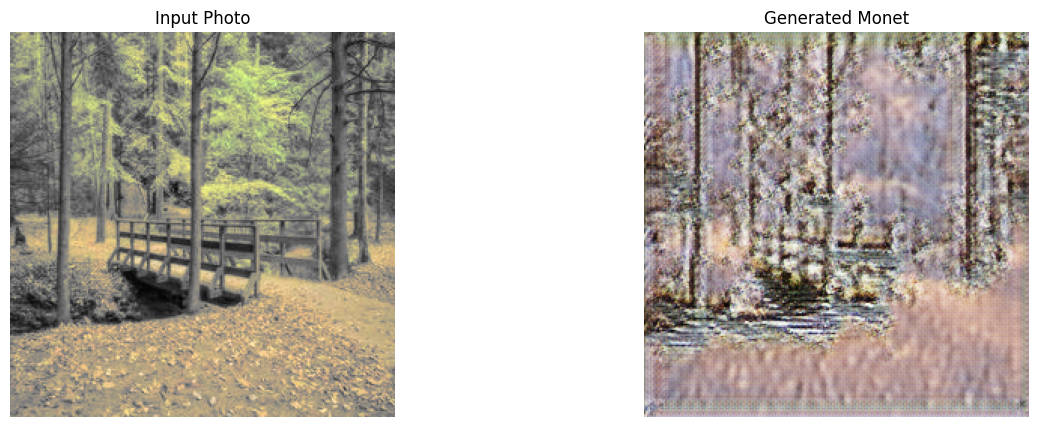

✅ Models saved at epoch 35

Epoch 36/50
Generator G Loss: 13.2105
Generator F Loss: 9.1379
Discriminator X Loss: 0.4553
Discriminator Y Loss: 0.0454

Epoch 37/50
Generator G Loss: 13.2501
Generator F Loss: 9.1002
Discriminator X Loss: 0.4309
Discriminator Y Loss: 0.0380

Epoch 38/50
Generator G Loss: 13.0410
Generator F Loss: 8.8643
Discriminator X Loss: 0.4734
Discriminator Y Loss: 0.0111

Epoch 39/50
Generator G Loss: 12.8092
Generator F Loss: 8.8339
Discriminator X Loss: 0.4600
Discriminator Y Loss: 0.0855

Epoch 40/50
Generator G Loss: 13.0201
Generator F Loss: 8.9943
Discriminator X Loss: 0.4530
Discriminator Y Loss: 0.0182

🔹 Generating sample images...


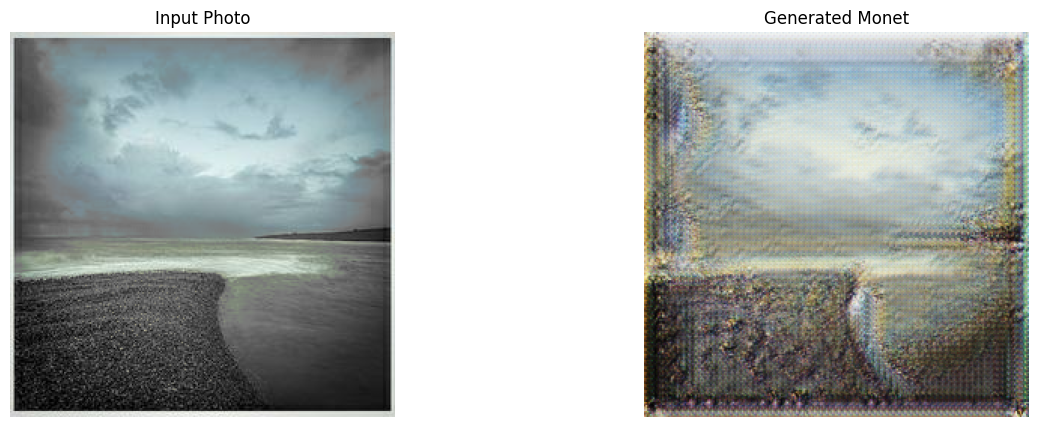

✅ Models saved at epoch 40

Epoch 41/50
Generator G Loss: 13.2286
Generator F Loss: 8.9685
Discriminator X Loss: 0.4414
Discriminator Y Loss: 0.0414

Epoch 42/50
Generator G Loss: 13.5809
Generator F Loss: 9.0844
Discriminator X Loss: 0.4518
Discriminator Y Loss: 0.0209

Epoch 43/50
Generator G Loss: 15.1347
Generator F Loss: 9.6064
Discriminator X Loss: 0.3974
Discriminator Y Loss: 0.0113

Epoch 44/50
Generator G Loss: 13.8630
Generator F Loss: 9.0615
Discriminator X Loss: 0.4057
Discriminator Y Loss: 0.0415

Epoch 45/50
Generator G Loss: 13.2822
Generator F Loss: 8.7753
Discriminator X Loss: 0.4473
Discriminator Y Loss: 0.0051

🔹 Generating sample images...


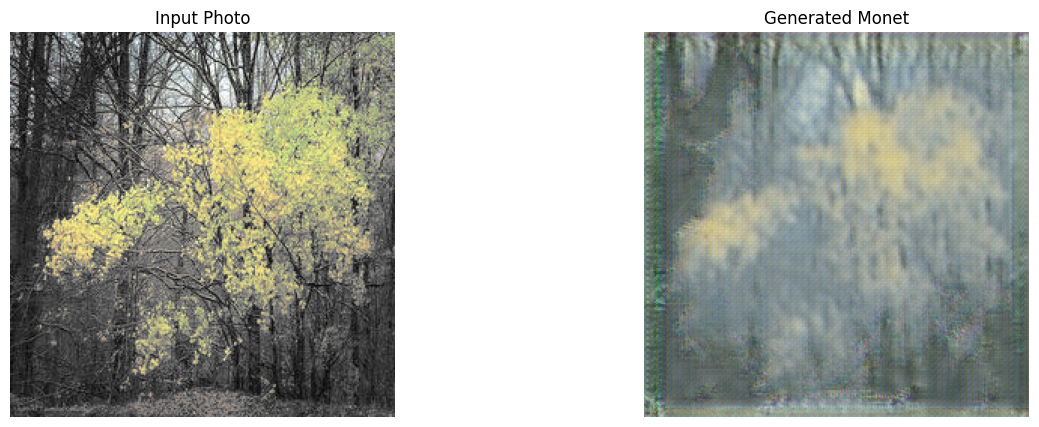

✅ Models saved at epoch 45

Epoch 46/50
Generator G Loss: 13.7856
Generator F Loss: 8.6814
Discriminator X Loss: 0.4821
Discriminator Y Loss: 0.0043

Epoch 47/50
Generator G Loss: 14.6601
Generator F Loss: 9.0605
Discriminator X Loss: 0.4555
Discriminator Y Loss: 0.0043

Epoch 48/50
Generator G Loss: 13.5594
Generator F Loss: 9.3094
Discriminator X Loss: 0.3896
Discriminator Y Loss: 0.1062

Epoch 49/50
Generator G Loss: 13.6954
Generator F Loss: 9.4845
Discriminator X Loss: 0.3862
Discriminator Y Loss: 0.0151

Epoch 50/50
Generator G Loss: 13.9447
Generator F Loss: 9.5178
Discriminator X Loss: 0.3276
Discriminator Y Loss: 0.0605

🔹 Generating sample images...


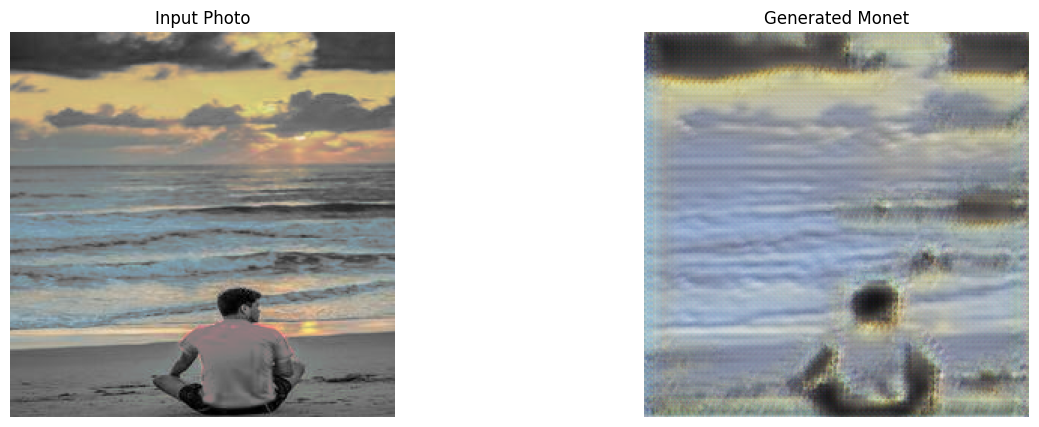

✅ Models saved at epoch 50
🎉 Training Complete!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# --------------------------
# 1. Loss Functions
# --------------------------
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    """Generator loss encouraging fooling the discriminator."""
    return loss_object(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    """Discriminator loss penalizing incorrect classification."""
    real_loss = loss_object(tf.ones_like(real_output), real_output)
    fake_loss = loss_object(tf.zeros_like(fake_output), fake_output)
    return (real_loss + fake_loss) * 0.5

def cycle_consistency_loss(real_image, cycled_image):
    """Cycle loss ensuring image consistency after transformations."""
    return tf.reduce_mean(tf.abs(real_image - cycled_image))

def identity_loss_fn(real_image, same_image):
    """Identity loss ensuring the generator does not change unchanged images."""
    return tf.reduce_mean(tf.abs(real_image - same_image))

# Set loss weights
cycle_loss_weight = 10.0
identity_loss_weight = 5.0

# --------------------------
# 2. Training Step Function
# --------------------------
@tf.function
def train_step(real_x, real_y):
    """Performs one training step for CycleGAN."""
    with tf.GradientTape(persistent=True) as tape:
        # Forward Cycle
        fake_y = generator_G(real_x, training=True)
        cycled_x = generator_F(fake_y, training=True)

        fake_x = generator_F(real_y, training=True)
        cycled_y = generator_G(fake_x, training=True)

        # Identity Mapping
        same_x = generator_F(real_x, training=True)
        same_y = generator_G(real_y, training=True)

        # Discriminator Predictions
        disc_real_x = discriminator_X(real_x, training=True)
        disc_fake_x = discriminator_X(fake_x, training=True)

        disc_real_y = discriminator_Y(real_y, training=True)
        disc_fake_y = discriminator_Y(fake_y, training=True)

        # Compute Losses
        gen_G_loss = generator_loss(disc_fake_y)
        gen_F_loss = generator_loss(disc_fake_x)

        cycle_loss = cycle_consistency_loss(real_x, cycled_x) + cycle_consistency_loss(real_y, cycled_y)
        identity_loss_value = identity_loss_weight * (identity_loss_fn(real_y, same_y) + identity_loss_fn(real_x, same_x))

        total_gen_G_loss = gen_G_loss + cycle_loss_weight * cycle_loss + identity_loss_value
        total_gen_F_loss = gen_F_loss + cycle_loss_weight * cycle_loss + identity_loss_value

        disc_X_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_Y_loss = discriminator_loss(disc_real_y, disc_fake_y)

    # Compute Gradients
    gen_G_gradients = tape.gradient(total_gen_G_loss, generator_G.trainable_variables)
    gen_F_gradients = tape.gradient(total_gen_F_loss, generator_F.trainable_variables)
    disc_X_gradients = tape.gradient(disc_X_loss, discriminator_X.trainable_variables)
    disc_Y_gradients = tape.gradient(disc_Y_loss, discriminator_Y.trainable_variables)

    # Apply Gradients (Backprop)
    generator_G_optimizer.apply_gradients(zip(gen_G_gradients, generator_G.trainable_variables))
    generator_F_optimizer.apply_gradients(zip(gen_F_gradients, generator_F.trainable_variables))
    discriminator_X_optimizer.apply_gradients(zip(disc_X_gradients, discriminator_X.trainable_variables))
    discriminator_Y_optimizer.apply_gradients(zip(disc_Y_gradients, discriminator_Y.trainable_variables))

    return total_gen_G_loss, total_gen_F_loss, disc_X_loss, disc_Y_loss

# --------------------------
# 3. Training Loop Execution
# --------------------------
EPOCHS = 50
SAVE_INTERVAL = 5

for epoch in range(EPOCHS):
    epoch_losses = {'G_G': [], 'G_F': [], 'D_X': [], 'D_Y': []}
    
    for image_x, image_y in tf.data.Dataset.zip((photo_ds, monet_ds)):
        gen_G_loss, gen_F_loss, disc_X_loss, disc_Y_loss = train_step(image_x, image_y)
        
        epoch_losses['G_G'].append(gen_G_loss.numpy())
        epoch_losses['G_F'].append(gen_F_loss.numpy())
        epoch_losses['D_X'].append(disc_X_loss.numpy())
        epoch_losses['D_Y'].append(disc_Y_loss.numpy())

    # Print Epoch Statistics
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print(f"Generator G Loss: {np.mean(epoch_losses['G_G']):.4f}")
    print(f"Generator F Loss: {np.mean(epoch_losses['G_F']):.4f}")
    print(f"Discriminator X Loss: {np.mean(epoch_losses['D_X']):.4f}")
    print(f"Discriminator Y Loss: {np.mean(epoch_losses['D_Y']):.4f}")

    # Save Checkpoint & Generate Sample Images
    if (epoch + 1) % SAVE_INTERVAL == 0:
        print("\n🔹 Generating sample images...")
        
        test_photo = next(iter(photo_ds))
        test_monet = next(iter(monet_ds))
        
        plt.figure(figsize=(15, 5))
        
        # Photo → Monet
        plt.subplot(1, 2, 1)
        plt.imshow(test_photo[0] * 0.5 + 0.5)
        plt.title("Input Photo")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        generated_monet = generator_G(test_photo, training=False)
        plt.imshow(generated_monet[0] * 0.5 + 0.5)
        plt.title("Generated Monet")
        plt.axis('off')

        plt.show()
        
        # Save Models
        generator_G.save(f"generator_G_epoch_{epoch+1}.h5")
        generator_F.save(f"generator_F_epoch_{epoch+1}.h5")
        print(f"✅ Models saved at epoch {epoch + 1}")

print("🎉 Training Complete!")